# Notebook to make Figure 5: Event vs. data-level p-values

In [1]:
import numpy as np 
import json 

import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib import style
style.use('../utils/plotting.mplstyle')
from matplotlib.lines import Line2D

import sys
sys.path.append('../utils')
import plot_utils 

## Setup

Load data

In [2]:
# Predicted vs. Observed PPC traces 
eventlevel_predobs = np.load('../data/PPC_traces_event_level.npz', allow_pickle=True)['arr_0'].item()
datalevel_predobs = np.load('../data/PPC_traces_data_level.npz', allow_pickle=True)['arr_0'].item()

Calculate test statistics $T$ and associated $p$-values

In [3]:
# Calculate test statistics
T_dict_eventlevel = plot_utils.get_test_statistics(eventlevel_predobs)
T_dict_datalevel = plot_utils.get_test_statistics(datalevel_predobs)

Plotting labels, aesthetics, etc.

In [4]:
bounds_dict = {
    'mean':[0.1,0.6],
    'standard deviation':[0.17,0.67], 
    'minimum':[-1,0], 
    plot_utils.zp_title:[0,3],
    r'fraction $|\cos\theta\,|>0.5$':[-0.05,1]
}
run_orders = {
    'gaussian_likelihood_sigma_0.1':2,
    'gaussian_likelihood_sigma_0.3':1,
    'gaussian_likelihood_sigma_0.5':0,
    'bilby_likelihood':-1
}
text_kws = dict(verticalalignment='top', zorder=6, fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.1', ec='white', fc='white', alpha=0.95))

## Make figure

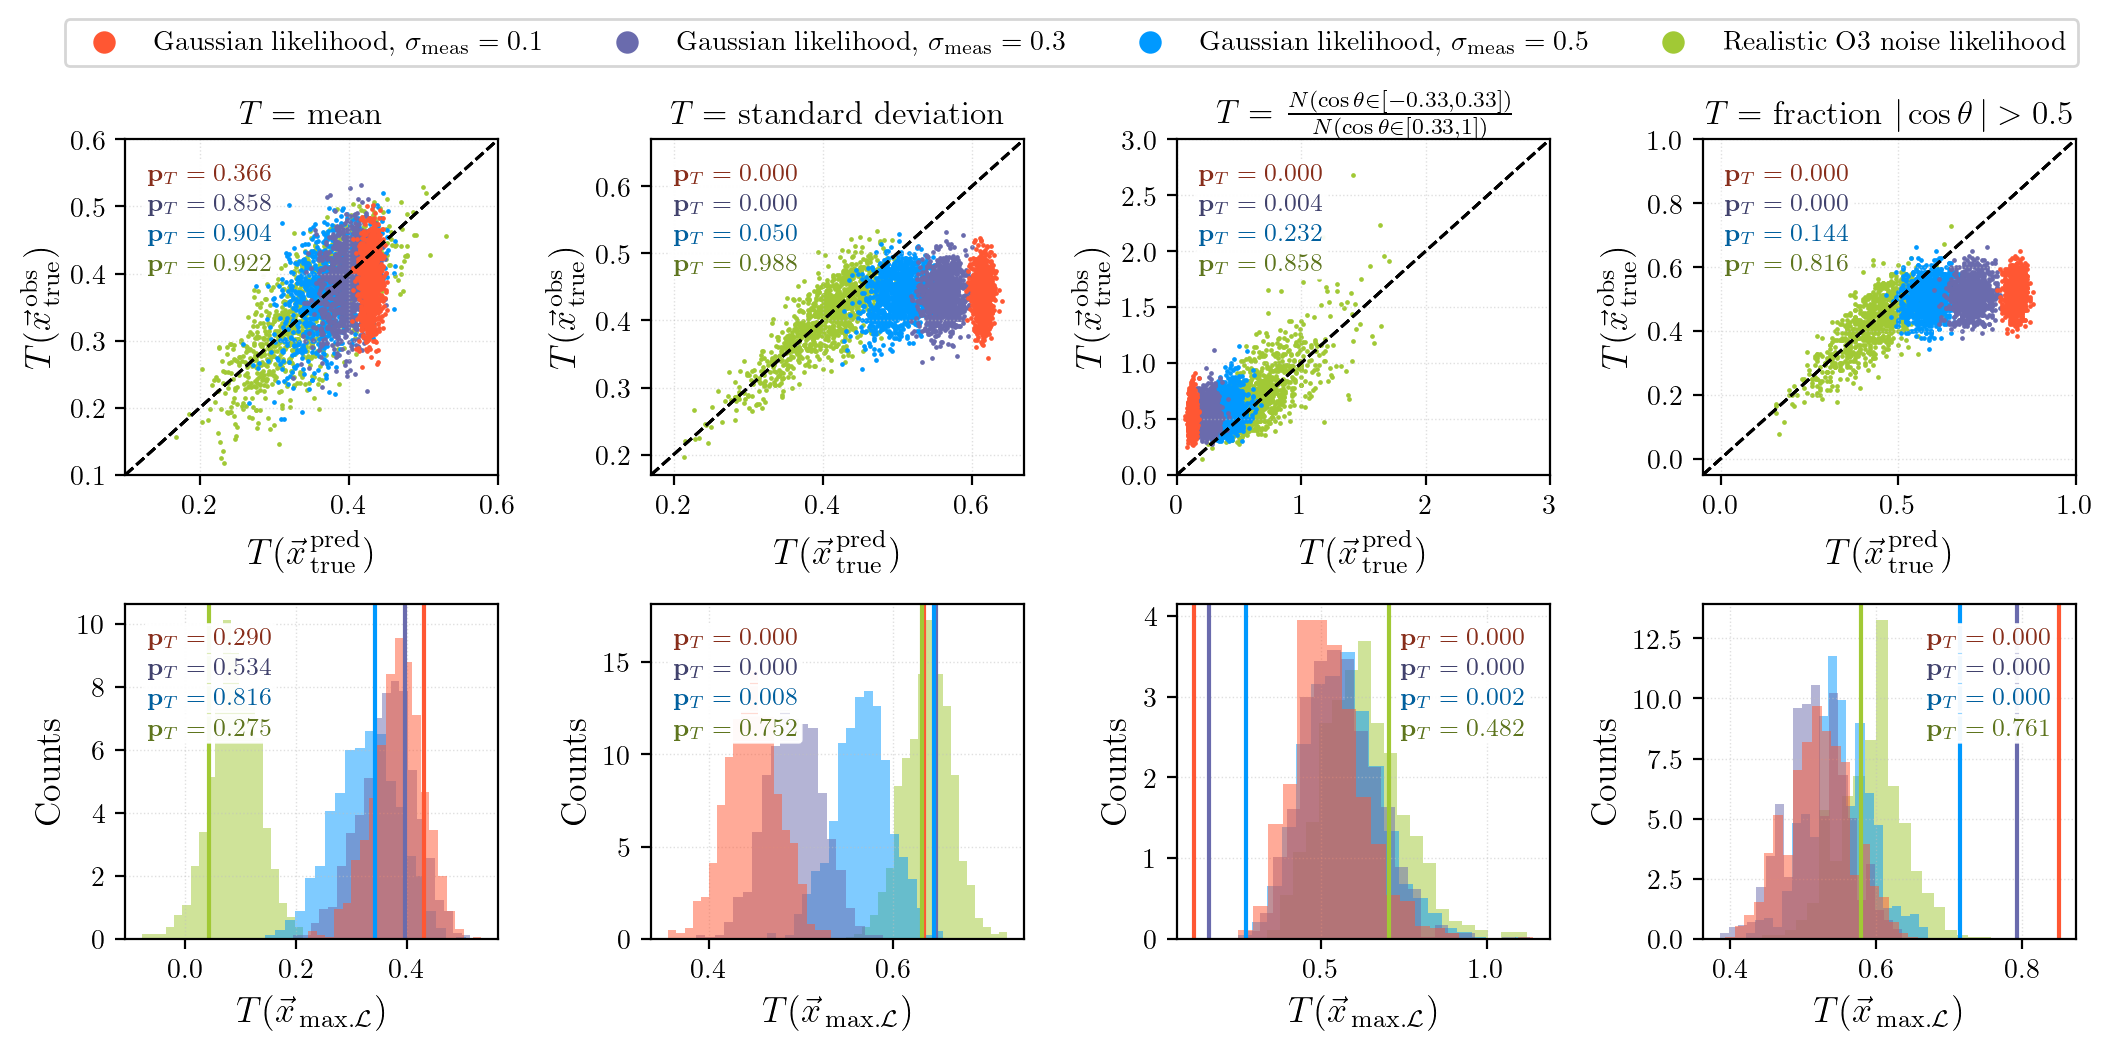

In [5]:
fig, axes = plt.subplots(2,4,figsize=(8*(4/3),5))

for j, (run, T_dict_event) in enumerate(T_dict_eventlevel.items()):
    color = plot_utils.run_colors[run]
    pcolor = plot_utils.run_colors_darker[run]
    for i, k in enumerate(T_dict_event.keys()): 

        # Event (true) level on top
        ax_top = axes[0,i]
        ax_top.scatter(T_dict_event[k]['T'], T_dict_event[k]['Trep'], s=0.5, 
                   color=color, label=plot_utils.run_labels_full[run], zorder=run_orders[run])
        
        diag = bounds_dict[k]
        ax_top.plot(diag, diag, color='k', lw=1, ls='--', zorder=5)
        ax_top.set_xlim(*diag)
        ax_top.set_ylim(*diag)
    
        p = T_dict_event[k]['pvalue']
        ax_top.text(0.06, 0.93-j*0.09, fr'$\mathbf{{p}}_T={p:.3f}$', 
                    transform=ax_top.transAxes, color=pcolor, **text_kws)

        ax_top.set_xlabel(r'$T(\vec{x}^{\,\mathrm{pred}}_{\,\mathrm{true}})$', fontsize=13)
        ax_top.set_ylabel(r'$T(\vec{x}^{\,\mathrm{obs}}_{\,\mathrm{true}})$', fontsize=13)
        ax_top.set_title(fr'$T=$ {k}')

        # Data (maxL) level on bottom
        ax_bottom = axes[1,i]
        T_dict_maxL = T_dict_datalevel[run]
        ax_bottom.hist(T_dict_maxL[k]['Trep'], color=color, bins=20, alpha=0.5, zorder=run_orders[run], density=True)
        ax_bottom.axvline(T_dict_maxL[k]['T'][0], color=color)
        
        p = T_dict_maxL[k]['pvalue']
        if i>=2:
            ax_bottom.text(0.6, 0.93-j*0.09, fr'$\mathbf{{p}}_T={p:.3f}$', 
                    transform=ax_bottom.transAxes, color=pcolor, **text_kws)
        else:
            ax_bottom.text(0.06, 0.93-j*0.09, fr'$\mathbf{{p}}_T={p:.3f}$', 
                    transform=ax_bottom.transAxes, color=pcolor, **text_kws)
        
        ax_bottom.set_ylabel('Counts', fontsize=13)
        ax_bottom.set_xlabel(r'$T(\vec{x}_{\,\mathrm{max.}\mathcal{L}})$', fontsize=13)


for ax in axes.flatten(): 
    ax.grid(color='silver', alpha=0.5, ls=':')
plt.tight_layout()
axes[0,0].legend(ncols = 4, loc='upper left', bbox_to_anchor=(-0.2,1.4), markerscale=10)
plt.savefig('figure_05.png', dpi=300, bbox_inches='tight')
plt.show()